# Notebook 03 — QLoRA 파인튜닝

## 목표
Qwen2.5-VL 7B를 NEU 불량 데이터로 **QLoRA** 파인튜닝한다.

## 왜 QLoRA인가?
- 7B 모델 풀 파인튜닝: **~56GB VRAM** 필요 → RTX 4080 Super(16GB)로 불가능
- QLoRA: 4-bit 양자화 + LoRA 어댑터만 학습 → **~8GB VRAM** 으로 가능
- 성능 손실: 풀 파인튜닝 대비 평균 1~3%p 이내

## 학습 전략
```
Qwen2.5-VL 7B (frozen, 4-bit)
        +
LoRA Adapter (rank=16, α=32)
  → Attention 레이어 (q_proj, v_proj, k_proj, o_proj)
  → 학습 파라미터: ~40M (전체의 0.5%)

Optimizer: AdamW 8-bit (bitsandbytes)
Scheduler: cosine with warmup
Epochs: 3 (Early stopping)
Batch: 1 + Gradient Accumulation 8 (effective batch=8)
```

In [1]:
%pip install -q matplotlib Pillow tqdm transformers peft accelerate bitsandbytes

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import json, os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import bitsandbytes as bnb
from tqdm import tqdm

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
DATA_PROCESSED = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "data" / "results"
MODEL_SAVE_DIR = ROOT / "models" / "checkpoints"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for f in ("train.json", "val.json"):
    assert (DATA_PROCESSED / f).exists(), (
        f"{f} 없음: {DATA_PROCESSED / f}\n먼저 01_dataset.ipynb를 실행해 데이터를 준비하세요."
    )

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

c:\Users\apple\anaconda3\envs\anomaly_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\apple\anaconda3\envs\anomaly_env\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte


GPU: NVIDIA GeForce RTX 4080 SUPER
VRAM: 17.2 GB


## 1. 모델 로드 + QLoRA 설정

In [3]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

# 4-bit 양자화: 베이스 모델 weights를 NF4로 압축
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,  # 학습 시 bf16 (안정성 우선)
    bnb_4bit_use_double_quant=True,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

# kbit 학습 준비 (gradient checkpointing + casting)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# LoRA 설정
lora_config = LoraConfig(
    r=16,                        # LoRA rank (클수록 표현력↑, VRAM↑)
    lora_alpha=32,               # LoRA scaling (alpha/r = 2 권장)
    target_modules=[             # Attention projection 레이어만 학습
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# 학습 가능 파라미터 수 확인
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n학습 파라미터: {trainable/1e6:.1f}M / {total/1e9:.2f}B ({trainable/total*100:.2f}%)")

Loading weights: 100%|██████████| 729/729 [00:14<00:00, 49.65it/s] 


trainable params: 47,589,376 || all params: 8,339,756,032 || trainable%: 0.5706

학습 파라미터: 47.6M / 4.74B (1.00%)


## 2. 데이터셋 클래스

In [4]:
SYSTEM_PROMPT = (
    "당신은 금속 제품 표면 불량을 분석하는 전문 AI입니다. "
    "주어진 이미지를 분석하여 불량 유형을 정확히 판단하고 "
    "반드시 JSON 형식으로만 답변하세요."
)


def resolve_image(path: str) -> Path:
    p = Path(path)
    return (ROOT / p) if not p.is_absolute() else p


class DefectVQADataset(Dataset):
    def __init__(self, json_path: str, processor, max_length: int = 512):
        with open(json_path, encoding="utf-8") as f:
            self.data = json.load(f)
        self.processor = processor
        self.max_length = max_length
        self._asst_ids = torch.tensor(
            processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        record = self.data[idx]
        img = Image.open(resolve_image(record["image"])).convert("RGB")
        user_text = record["conversations"][0]["content"]
        assistant_text = record["conversations"][1]["content"]

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {"type": "text",  "text": user_text},
                ],
            },
            {"role": "assistant", "content": assistant_text},
        ]

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        inputs = self.processor(
            text=[text],
            images=[img],
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
        )
        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)

        pixel_values = inputs.get("pixel_values")
        if pixel_values is not None:
            pixel_values = pixel_values.squeeze(0)

        # Qwen2.5-VL 이미지 패치 격자 정보 (없으면 forward에서 NoneType 에러)
        image_grid_thw = inputs.get("image_grid_thw")
        if image_grid_thw is not None:
            image_grid_thw = image_grid_thw.squeeze(0)

        labels = input_ids.clone()
        n = len(self._asst_ids)
        found = False
        for i in range(len(labels) - n):
            if (input_ids[i : i + n] == self._asst_ids).all():
                labels[: i + n] = -100
                found = True
                break
        if not found:
            labels[:] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "pixel_values": pixel_values,
            "image_grid_thw": image_grid_thw,
            "labels": labels,
        }


train_dataset = DefectVQADataset(DATA_PROCESSED / "train.json", processor)
val_dataset   = DefectVQADataset(DATA_PROCESSED / "val.json",   processor)

print(f"Train: {len(train_dataset)}개")
print(f"Val  : {len(val_dataset)}개")

sample = train_dataset[0]
print(f"\n입력 shape    : {sample['input_ids'].shape}")
print(f"레이블 shape  : {sample['labels'].shape}")
print(f"grid_thw shape: {sample['image_grid_thw'].shape}")
print(f"레이블 유효 토큰: {(sample['labels'] != -100).sum().item()}개")

Train: 1260개
Val  : 270개

입력 shape    : torch.Size([512])
레이블 shape  : torch.Size([512])
grid_thw shape: torch.Size([3])
레이블 유효 토큰: 344개


## 3. 학습 루프

In [5]:
# 하이퍼파라미터
EPOCHS = 3
BATCH_SIZE = 1
GRAD_ACCUM = 8          # effective batch = 8
LR = 2e-4
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0

def collate_fn(batch):
    keys = batch[0].keys()
    result = {}
    for k in keys:
        vals = [b[k] for b in batch if b[k] is not None]
        if vals:
            result[k] = torch.stack(vals)
    return result

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

# 8-bit AdamW (메모리 효율)
optimizer = bnb.optim.AdamW8bit(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=0.01,
)

total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"총 스텝: {total_steps}  |  워밍업: {warmup_steps}")
print(f"예상 학습 시간: {total_steps * 1.5 / 60:.0f}분 (GPU 기준 추정)")

총 스텝: 472  |  워밍업: 47
예상 학습 시간: 12분 (GPU 기준 추정)


In [6]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
global_step = 0

_device = next(model.parameters()).device

def _optimizer_step():
    torch.nn.utils.clip_grad_norm_(
        [p for p in model.parameters() if p.requires_grad],
        MAX_GRAD_NORM,
    )
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

for epoch in range(EPOCHS):
    # === Train ===
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for step, batch in enumerate(pbar):
        batch = {k: v.to(_device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss / GRAD_ACCUM
        loss.backward()
        epoch_loss += outputs.loss.item()

        if (step + 1) % GRAD_ACCUM == 0:
            _optimizer_step()
            global_step += 1

        pbar.set_postfix(loss=f"{outputs.loss.item():.4f}",
                         lr=f"{scheduler.get_last_lr()[0]:.2e}")

    # 에포크 끝 — GRAD_ACCUM으로 나누어 떨어지지 않는 나머지 배치 처리
    if len(train_loader) % GRAD_ACCUM != 0:
        _optimizer_step()
        global_step += 1

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # === Validation ===
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            batch = {k: v.to(_device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss_sum += outputs.loss.item()
    avg_val_loss = val_loss_sum / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch+1}: train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained(MODEL_SAVE_DIR / "best")
        processor.save_pretrained(MODEL_SAVE_DIR / "best")
        print(f"  ✓ Best 모델 저장 (val_loss={best_val_loss:.4f})")

print("\n학습 완료!")
print(f"Best val_loss: {best_val_loss:.4f}")

Epoch 1/3 [train]:   0%|          | 0/1260 [00:00<?, ?it/s]c:\Users\apple\anaconda3\envs\anomaly_env\Lib\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Epoch 1/3 [val]: 100%|██████████| 270/270 [01:16<00:00,  3.54it/s]



Epoch 1: train_loss=0.4495  val_loss=0.0003
  ✓ Best 모델 저장 (val_loss=0.0003)


Epoch 2/3 [val]: 100%|██████████| 270/270 [01:14<00:00,  3.64it/s]



Epoch 2: train_loss=0.0001  val_loss=0.0001
  ✓ Best 모델 저장 (val_loss=0.0001)


Epoch 3/3 [val]: 100%|██████████| 270/270 [01:14<00:00,  3.64it/s]


Epoch 3: train_loss=0.0000  val_loss=0.0001

학습 완료!
Best val_loss: 0.0001


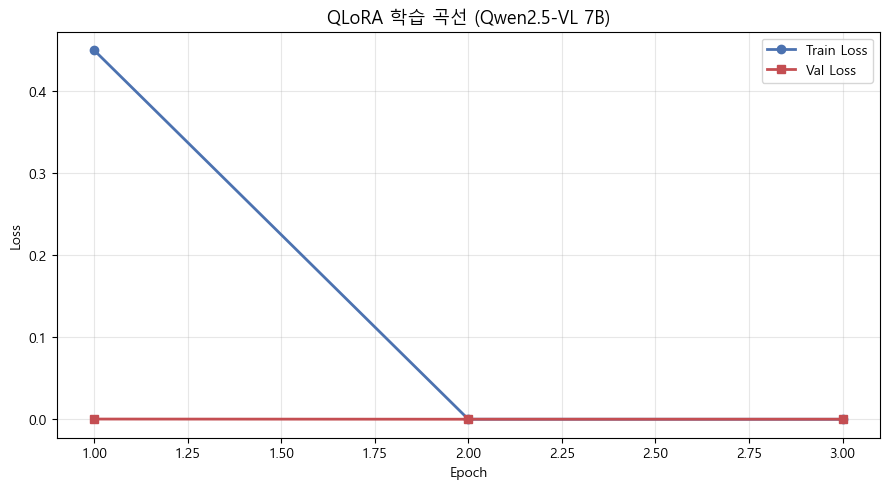

저장: data/results/training_curve.png
저장: data/results/training_history.json

다음 단계: 04_evaluation.ipynb → Before vs After 비교


In [7]:
# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(9, 5))
epochs_x = list(range(1, len(train_losses) + 1))
ax.plot(epochs_x, train_losses, "o-", label="Train Loss", color="#4C72B0", linewidth=2)
ax.plot(epochs_x, val_losses,   "s-", label="Val Loss",   color="#C44E52", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("QLoRA 학습 곡선 (Qwen2.5-VL 7B)", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장: data/results/training_curve.png")

# 학습 이력 저장
history = {"train_loss": train_losses, "val_loss": val_losses}
with open(RESULTS_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("저장: data/results/training_history.json")
print("\n다음 단계: 04_evaluation.ipynb → Before vs After 비교")